In [1]:
#다음 라이브러리를 설치해주세요
!pip install sentencepiece
!pip install tqdm
!conda install -y -c conda-forge ipywidgets
!jupyter nbextension enable --py widgetsnbextension
!pip install torchsummary
!pip install torchinfo

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information abou

**Exp 구성**

1. CTRL : Origin : LMS 기본 코드
2. EXP1  : Activation function  변경 : GELU → SwiGlu
3. EXP2 : Postional Embedding 변경 : Rotary Positional Encdoing 
4. EXP3 : FeedForward 층 변경 : MoE 변경

2.7.1+cu118


  0%|          | 0/3957761 [00:00<?, ?it/s]

['▁화학']
['▁화학', '(', '化', '學', ',', '▁)', '은', '▁물질', '의', '▁성', '질', ',', '▁조성', ',', '▁구조', ',', '▁변화', '▁및', '▁그', '에', '▁수', '반', '하는', '▁에너', '지의', '▁변', '화를', '▁연구', '하는', '▁자연', '과', '학의', '▁한', '▁분야', '이다', '.', '▁물리', '학', '도', '▁역시', '▁물질', '을', '▁다루', '는', '▁학', '문', '이지만', ',', '▁물리', '학', '이', '▁원', '소', '와', '▁화', '합', '물을', '▁모두', '▁포함한', '▁물', '체의', '▁운동', '과', '▁에너', '지', ',', '▁열', '적', '·', '전', '기', '적', '·', '광', '학적', '·', '기', '계', '적', '▁속', '성을', '▁다루', '고', '▁이러한', '▁현', '상', '으로부터', '▁통일', '된', '▁이론', '을', '▁구축', '하려는', '▁것', '과는', '▁달리', '▁화학', '에서는', '▁물질', '▁자', '체를', '▁연구', '▁대상으로', '▁한다', '.', '▁화학', '은', '▁이미', '▁존재', '하는', '▁물질', '을', '▁이용하여', '▁특', '정한', '▁목', '적', '에', '▁맞', '는', '▁새로운', '▁물질', '을', '▁합', '성', '하는', '▁길', '을', '▁제공', '하며', ',', '▁이는', '▁농', '작', '물의', '▁증', '산', ',', '▁질', '병', '의', '▁치료', '▁및', '▁예', '방', ',', '▁에너', '지', '▁효', '율', '▁증', '대', ',', '▁환경', '오', '염', '▁감소', '▁등', '▁여러', '▁가지', '▁이', '점을', '▁제공', '한다', '.']
['▁유', '기',

  0%|          | 0/227615 [00:00<?, ?it/s]

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000
슝=3
슝=3
슝=3
슝=3
슝=3
슝=3


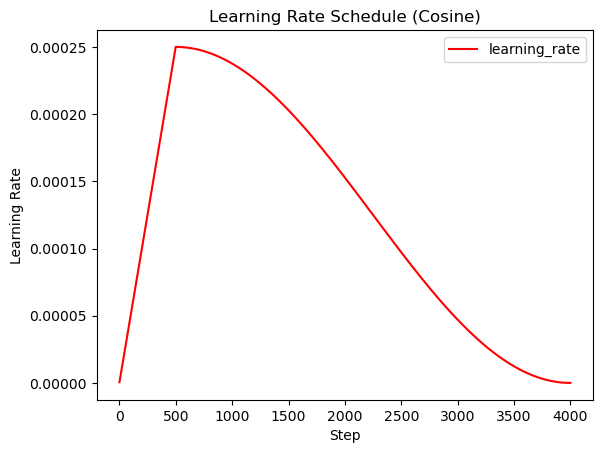

train_steps: 40000
Epoch 1/10 - Loss: 8.373452981710434, NSP Loss: 0.6594815449565649, MLM Loss: 7.713971441268921, NSP Accuracy: 0.600765625, MLM Accuracy: 0.8432128295898438
Epoch 2/10 - Loss: 8.301061989784241, NSP Loss: 0.6527066339403391, MLM Loss: 7.648355360388756, NSP Accuracy: 0.617484375, MLM Accuracy: 0.8693136596679687
Epoch 3/10 - Loss: 8.296878960609437, NSP Loss: 0.648633071243763, MLM Loss: 7.648245878219605, NSP Accuracy: 0.6307421875, MLM Accuracy: 0.8693136596679687
Epoch 4/10 - Loss: 8.293571267604827, NSP Loss: 0.6453466075658798, MLM Loss: 7.648224659204483, NSP Accuracy: 0.6422109375, MLM Accuracy: 0.8693136596679687
Epoch 5/10 - Loss: 8.290197639465331, NSP Loss: 0.6419787620157004, MLM Loss: 7.648218873500824, NSP Accuracy: 0.6524921875, MLM Accuracy: 0.8693136596679687
Epoch 6/10 - Loss: 8.28764028596878, NSP Loss: 0.6394220260381699, MLM Loss: 7.648218259215355, NSP Accuracy: 0.660859375, MLM Accuracy: 0.8693136596679687
Epoch 7/10 - Loss: 8.283873311519622, 

In [2]:
'''
$ mkdir -p ~/work/bert_pretrain/data
$ mkdir -p ~/work/bert_pretrain/models
$ wget https://aiffelstaticprd.blob.core.windows.net/media/documents/kowiki.txt.zip
$ mv kowiki.txt.zip ~/work/bert_pretrain/data
$ cd ~/work/bert_pretrain/data && unzip kowiki.txt.zip

$ pip install sentencepiece
$ pip install tqdm
$ conda install -c conda-forge ipywidgets
$ jupyter nbextension enable --py widgetsnbextension

'''
#############################################
########### Tokenizer 준비 ###################
#############################################


# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

'''
$ python
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = os.getenv('HOME')+'/work/bert_pretrain/data/kowiki.txt'
>>> prefix = os.getenv('HOME')+'/work/bert_pretrain/models/ko_32000'
>>> vocab_size = 32000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")
'''

import sentencepiece as spm
import os
corpus_file = 'data/kowiki.txt'
prefix = 'data/ko_8000'
vocab_size = 8000
#센텐스피스를 직접 만들어보실 분들은 주석을 풀어 진행해보세요! 
#(LMS 환경에서는 시간이 오래 걸려요)
#spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")



data_dir = '/home/jovyan/data'


# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{data_dir}/ko_8000.model")



################# example ########################

# # 토크나이저가 잘 만들어졌는지 확인. 어떤 토크닝 만들어졌는지, 토크나이징 결과가 어떻게 나오는지
# #Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
# vocab_list = []
# for id in range(7, len(vocab)):
#         if not vocab.is_unknown(id):
#             vocab_list.append(vocab.id_to_piece(id))
# print(vocab_list)


# # [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
# string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
# string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
# tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
# # print(tokens_org)

# 위 결과가 sentencePiece 모델을 이용해 간단한 BERT 의 Masked Language Model 학습용 데이터를 하나 생성


#######################################################################3
####################3. 데이터 전처리 ####################################
#######################################################################3


# (1) MASK 생성

'''
BERT의 Masked Language Model(MLM) 은 GPT 의 Next Token Prediction 테스크처럼 다ㅇㅁ 이어질 단어?를 맞추는게 아니라
마스킹 된 다음 빈칸에 알맞은 단어는? 문제를 푸는 형식으로 구성됩니다

MLM 을 위해 BERT는 학습 데이터 전체의 15% 를 [MASK] 토큰으로 랜덤하게 바꾼다. 이 15% 의 [MASK] 토큰 중 80% 는 [MASK] 토큰,
10% 는 무작위로 랜덤한 토큰, 나머지 10% 는 원래의 토큰을 그대로 사용

이전 스템의 Masked LM 데이터셋 예시에서 출발
'''


# print(tokens_org)

# 전체 token의 15% mask
# mask_cnt = int((len(tokens_org) - 3) * 0.15)
# mask_cnt

'''
15%를 마스킹 한다고 해도 생각해 볼 것이 더 있습니다.Subword 기반으로 토크나이징 했을 때, _대, [MASK], 민국이라고 
가운데를 마스킹 했을 경우 해당 [MASK]가 '한' 일거라는 건 너무 쉽게 맟출 수 있습니다.
'대한민국' 이란느 패턴을 아주 자주 보게 될 테니까요
그래서 Masked LM 테스크를 구성할 땐 띄어쓰기 단위로 한꺼번에 마스킹 해주는 것이 좋습니다
'''

# # 띄어쓰기 단위로 mask하기 위해서 index 분할
# cand_idx = []  # word 단위의 index array
# for (i, token) in enumerate(tokens_org):
#     if token == "[CLS]" or token == "[SEP]":
#         continue
#     if 0 < len(cand_idx) and not token.startswith(u"\u2581"):  # u"\u2581"는 단어의 시작을 의미하는 값
#         cand_idx[-1].append(i)
#     else:
#         cand_idx.append([i])

# # 결과확인
# for cand in cand_idx:
#     print(cand, [tokens_org[i] for i in cand])



# # random mask를 위해서 index 순서를 섞음
# random.shuffle(cand_idx)
# cand_idx



# # tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
# tokens = copy.deepcopy(tokens_org)

# mask_lms = []  # mask 된 값
# for index_set in cand_idx:
#     if len(mask_lms) >= mask_cnt:  # 핸재 mask된 개수가 15%를 넘으면 중지
#           break
#     if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
#           continue
#     dice = random.random()  # 0과 1 사이의 확률 값

#     for index in index_set:
#         masked_token = None
#         if dice < 0.8:  # 80% replace with [MASK]
#             masked_token = "[MASK]"
#         elif dice < 0.9: # 10% keep original
#             masked_token = tokens[index]
#         else:  # 10% random word
#             masked_token = random.choice(vocab_list)
#         mask_lms.append({"index": index, "label": tokens[index]})
#         tokens[index] = masked_token

# print("tokens_org")
# print(tokens_org, "\n")
# print("tokens")
# print(tokens)


# Masked LM의 라벨 데이터도 아래와 같이 생성
# # 순서 정렬 및 mask_idx, mask_label 생성
# mask_lms = sorted(mask_lms, key=lambda x: x["index"])
# mask_idx = [p["index"] for p in mask_lms]
# mask_label = [p["label"] for p in mask_lms]

# print("mask_idx   :", mask_idx)
# print("mask_label :", mask_label)


###############################################
#### create_pretrain_mask() : masked lm을 위한 코퍼스 생성 메소드

# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label



# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
# tokens = copy.deepcopy(tokens_org)

# tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

# print("tokens_org")
# print(tokens_org, "\n")
# print("tokens")
# print(tokens, "\n")

# print("mask_idx   :", mask_idx)
# print("mask_label :", mask_label)


###############################################################
############# (2) NSP pair 생성 ################################
###############################################################

string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""


# # 줄 단위로 tokenize
# doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
# doc[:3]


# # 이 단계에서 넣어줄 특수 token 은 [CLS] 와 [EPS] 이고, sequence 의 최대 길이는 n_test_seq - 3 으로 정합니다
# # 최대 길이
# n_test_seq = 64
# # 최소 길이
# min_seq = 8
# # [CLS], tokens_a, [SEB], tokens_b, [SEP]
# max_seq = n_test_seq - 3


# current_chunk = []  # line 단위 tokens
# current_length = 0
# for i in range(len(doc)):  # doc 전체를 loop
#     current_chunk.append(doc[i])  # line 단위로 추가
#     current_length += len(doc[i])  # current_chunk의 token 수
#     if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우, 학습 데이터를 만듭니다.
#         print("current_chunk:", len(current_chunk), current_length, current_chunk)

#         #######################################
#         # token a
#         a_end = 1
#         if 1 < len(current_chunk):
#             a_end = random.randrange(1, len(current_chunk))
#         tokens_a = []
#         for j in range(a_end):
#             tokens_a.extend(current_chunk[j])
#         # token b
#         tokens_b = []
#         for j in range(a_end, len(current_chunk)):
#             tokens_b.extend(current_chunk[j])

#         print("tokens_a:", len(tokens_a), tokens_a)
#         print("tokens_b:", len(tokens_b), tokens_b)
#         #######################################
#         print()

#         current_chunk = []
#         current_length = 0
        
        
'''
짝지은 두 문장을 그대로 두면 NSP TASK 의 TRUE LABEL 케이스가 되고, 둘의 순서를 뒤바꾸면 false label 케이스가 되겠죠?

두 문장의 최대 길이를 유지하도고 trim을 적용한 후 50%의 확률로 true/false 케이스를 생성해보겠다
token A 의 길이가 max_seq 보다 길면 앞에부터 토큰을 제거하고, token B 의 길이가 길면 뒤에서부터 토큰을 제거한다
'''

def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()
            

# current_chunk = []  # line 단위 tokens
# current_length = 0
# for i in range(len(doc)):  # doc 전체를 loop
#     current_chunk.append(doc[i])  # line 단위로 추가
#     current_length += len(doc[i])  # current_chunk의 token 수
#     if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
#         print("current_chunk:", len(current_chunk), current_length, current_chunk)

#         # token a
#         a_end = 1
#         if 1 < len(current_chunk):
#             a_end = random.randrange(1, len(current_chunk))
#         tokens_a = []
#         for j in range(a_end):
#             tokens_a.extend(current_chunk[j])
#         # token b
#         tokens_b = []
#         for j in range(a_end, len(current_chunk)):
#             tokens_b.extend(current_chunk[j])

#         #######################################
#         if random.random() < 0.5:  # 50% 확률로 swap
#             is_next = 0     #False
#             tokens_t = tokens_a
#             tokens_a = tokens_b
#             tokens_b = tokens_t
#         else:
#             is_next = 1    #True
#         # max_seq 보다 큰 경우 길이 조절
#         trim_tokens(tokens_a, tokens_b, max_seq)
#         assert 0 < len(tokens_a)
#         assert 0 < len(tokens_b)

#         print("is_next:", is_next)
#         print("tokens_a:", len(tokens_a), tokens_a)
#         print("tokens_b:", len(tokens_b), tokens_b)
#         #######################################
#         print()

#         current_chunk = []
#         current_length = 0
        
'''
이제 두 문장 사이에 segment 처리를 해줘어야한다 .첫번재 문장의 segment 는 모두 0으로, 두번째 문장은 1로 채워준 후
둘 사이에 구분된 [SEP] 등을 넣어주는 것으로 마무리된다

이전 스템의 create_pretrain_mask() 까지 함께 호출되어 mask lm용 데이터셋과 nsp 용 데이터셋이 결합된 하나의 데이터셋으로 완성
BERT 의 pretrain 은 MLM 과 NSP 두가지 task가 동시에 수행된다
'''

# instances = []
# current_chunk = []  # line 단위 tokens
# current_length = 0
# for i in range(len(doc)):  # doc 전체를 loop
#     current_chunk.append(doc[i])  # line 단위로 추가
#     current_length += len(doc[i])  # current_chunk의 token 수
#     if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
#         print("current_chunk:", len(current_chunk), current_length, current_chunk)

#         # token a
#         a_end = 1
#         if 1 < len(current_chunk):
#             a_end = random.randrange(1, len(current_chunk))
#         tokens_a = []
#         for j in range(a_end):
#             tokens_a.extend(current_chunk[j])
#         # token b
#         tokens_b = []
#         for j in range(a_end, len(current_chunk)):
#             tokens_b.extend(current_chunk[j])

#         if random.random() < 0.5:  # 50% 확률로 swap
#             is_next = 0    # False
#             tokens_t = tokens_a
#             tokens_a = tokens_b
#             tokens_b = tokens_t
#         else:
#             is_next = 1   # True
#         # max_seq 보다 큰 경우 길이 조절
#         trim_tokens(tokens_a, tokens_b, max_seq)
#         assert 0 < len(tokens_a)
#         assert 0 < len(tokens_b)

#         print("is_next:", is_next)
#         print("tokens_a:", len(tokens_a), tokens_a)
#         print("tokens_b:", len(tokens_b), tokens_b)
#         #######################################

#         # tokens & segment 생성
#         tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
#         segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
#         print("tokens:", len(tokens), tokens)
#         print("segment:", len(segment), segment)

#         # mask
#         tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * 0.15), vocab_list)
#         print("masked tokens:", len(tokens), tokens)
#         print("masked index:", len(mask_idx), mask_idx)
#         print("masked label:", len(mask_label), mask_label)

#         instance = {
#             "tokens": tokens,
#             "segment": segment,
#             "is_next": is_next,
#             "mask_idx": mask_idx,
#             "mask_label": mask_label
#         }
#         instances.append(instance)
#         #######################################
#         print()

#         current_chunk = []
#         current_length = 0
        
        
# # 최종 데이터셋 결과 확인
# for instance in instances:
#     print(instance)
    
    

####################################################################
# create_pretain_instances() : next sentence prediction 을 위한 코퍼스 생성 메서드
###################################################################


# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

# instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# # 최종 데이터셋 결과 확인
# for instance in instances:
#     print(instance)
    


#########################################################################
###################3#### (3) 데이터셋 완성 ################################
#########################################################################


corpus_file = '/home/jovyan/work/bert_pretrain/data/kowiki.txt'

# # line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1



# 위키 문서는 하나의 도큐먼트가 주제 키워드에 대해 상세 내용이 설명으로 따라 붙어 있는 형태로 구성되어있다
# 도큐먼트 주제별로 잘 나눠지는지도 확인

# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    # print(len(doc), "lines :", doc[0])
                    # print(doc[1])
                    # print(doc[-1])
                    # print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []
        
        
        
# 이전 스텝에서 완성했던 create_pretrain_instances() 를 코퍼스에 저굥ㅇ할 수 있는지 몇라인데 대해서만 확인


# # # instance 생성 기능 확인
# count = 3

# with open(corpus_file, 'r') as in_f:
#     doc = []  # 단락 단위로 문서 저장
#     for line in tqdm(in_f, total=total):
#         line = line.strip()
#         if line == "":  # line이 빈줄 일 경우 (새로운 단락)
#             if 0 < len(doc):
#                 instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)
#                 # save
#                 print("doc:", len(doc), "instances:", len(instances))
#                 print(instances[0])
#                 print(instances[-1])
#                 print()
#                 doc = []
#                 if 0 < count:  # 테스트를 위해서 부분 처리함
#                     count -= 1
#                 else:
#                     break
#         else:  # doc에 저장
#             if 0 < len(pieces):
#                 doc.append(pieces)
#     if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
#         instances = create_pretrain_instances(doc, 128)
#         # save
#         print("doc:", len(doc), "instances:", len(instances))
#         print(instances[0])
#         print(instances[-1])
#         print()
#         doc = []
        
        
###########################################333
# make_pretrain_data () : BERT pretrain 데이터셋 생성 메소드
# 전체 전처리 과정을 거쳐 최종적으로 만들어지는 BERT pretrain 데이터셋 생성 메소드는 다음과 같다

# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []
                
                
# 최종적으로 생성된 데이터셋은 json 포멧으로 저장
pretrain_json_path = '/home/jovyan/work/bert_pre_train.json'

# make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)



# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total


'''
우리가 다뤄야할 데이터셋은 사이즈가 크다.만들어질 데이터셋 파일의 크기가 1.4GB 정도 된다. 실제 BERT 학습용의 1/100 정도밖에 안되겟지만
그럼에도 불구하고 이렇게 큰 파일을 로딩하는 함수를 만들 때는 메모리 사용량과 관련해 고려해야 할 점이 있다.

그래서 우리는 np.memmap 을 사용해서 메모리 사용량을 최소화하는 방법을 시도해 볼 것이다
'''

n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))


# print(enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1])



# 만들어진 json 파일을 라인 단위로 읽어 들여 np.memmap 레 로딩해봅시다
# 라인 단위로 처리
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        # print(data)
        # print("enc_token:", enc_token)
        # print("segment:", segment)
        # print("label_nsp:", label_nsp)
        # print("label_mlm:", label_mlm)
        # print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm
        
        
# load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수
# np.memmap 을 사용해 메모리 효율적으로 만들어진 데이터를 로딩하는 함수를 아래와 같이 구성


def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


# 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

# 처음과 마지막 확인
# pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]




###############################################################################
########################### 4. BERT 모델 구현 ##################################
###############################################################################

def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

# print("슝=3")

def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

# print("슝=3")


def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

# print("슝=3")


def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

# print("슝=3")


class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
# print("슝=3")

class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
# print("슝=3")


'''
position embedding 레이어는 다음과 같습니다
Trnasformer 이 사인 함수와 코사인 함수를 이용한 Positional Encoding 을 통해 토큰의 상대적인 위치를 학습했던 것과 달리
BERT 에서는 Positional Embedding 을 사용합니다. Position Embedding 은 위치 정보가 담긴 임베딩 레이어를하나 더 사용해
Position Embedding 벡터를 학습시켜서, BERT 의 입력에 Position Embedding 을 더해줍니다

'''
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

# print("슝=3")

import torch
import torch.nn as nn


class RotaryPositionEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        seq_len = x.size(1)
        # position index
        position = torch.arange(
            seq_len,
            device=x.device
        ).float()

        # frequency
        inv_freq = 1.0 / (
            10000 ** (
                torch.arange(0, self.dim, 2).float().to(x.device)
                / self.dim
            )
        )

        sinusoid_inp = torch.einsum(
            "i,j->ij",
            position,
            inv_freq
        )

        sin = torch.sin(sinusoid_inp)
        cos = torch.cos(sinusoid_inp)

        # even/odd split
        x1 = x[..., ::2]
        x2 = x[..., 1::2]

        # rotation
        x_rot = torch.cat([
            x1 * cos - x2 * sin,
            x1 * sin + x2 * cos
        ], dim=-1)

        return x_rot
    
'''
상대적으로 매우 간단한 Segment Embedding 은 별도의 레이어를 구현하지 않고 BERT 클래스에서 간단히 포함하도록 한다
Segment Embedding 은 두개의 문장을 구분하기 위한 임베딩

'''
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

# print("슝=3")


# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
# print("슝=3")


class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out
print("슝=3")



class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.d_model = config.d_model
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens)* math.sqrt(self.d_model) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed
# print("슝=3")

# pretrain 용 BERT모델 구성은 아래와 같다
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        outputs = F.softmax(outputs, dim=-1)
        return outputs

# print("슝=3")


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = F.softmax(logits_cls, dim=-1)

        outputs_mlm = F.softmax(logits_lm, dim=-1)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")


class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": 5000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

vocab = Vocab(config.n_vocab)
config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id

n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# # 학습 루프
# epochs = 2
# for epoch in range(epochs):
#     model.train()
#     total_loss = 0

#     for batch in train_dataloader:
#         enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
#         optimizer.zero_grad()
#         logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
#         loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
#         loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
#         total_loss_batch = loss_nsp + loss_mlm
#         total_loss += total_loss_batch.item()

#         total_loss_batch.backward()

#         optimizer.step()

#     print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")
    
    
    
##################################################################33
################# PRETRAIN 진행 ####################################
###################################################################

def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

print("슝=3")

# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

## 모델 생성을 위한 라이브러리 설치
#!pip install torchinfo




# 모델 생성
from torchinfo import summary

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])


epochs = 10
batch_size = 32

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)
learning_rate_scheduler = CosineSchedule(optimizer=optimizer,train_steps=train_steps, warmup_steps=max(100, train_steps // 10))


loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader)}, MLM Loss: {total_mlm_loss / len(train_dataloader)}, "
          f"NSP Accuracy: {total_nsp_acc / len(train_dataloader)}, MLM Accuracy: {total_mlm_acc / len(train_dataloader)}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"/home/jovyan/work/20260520_bert/result/origin/bert_pre_train_epoch_{epoch+1}.pt")


import matplotlib.pyplot as plt

# # training result
# plt.figure(figsize=(12, 4))

# plt.subplot(1, 2, 1)
# plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
# plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
# plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

# plt.show()


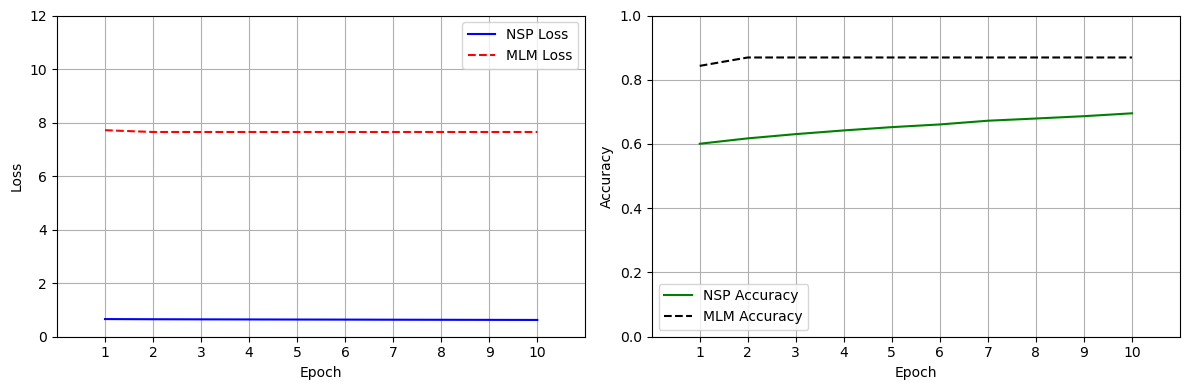

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epoch = np.arange(1, 11)

# -------------------
# Loss Plot
# -------------------
axes[0].plot(epoch, history['nsp_loss'], 'b-', label='NSP Loss')
axes[0].plot(epoch, history['mlm_loss'], 'r--', label='MLM Loss')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[0].set_xlim(0, 11)
axes[0].set_ylim(0, 12)

# 모든 epoch tick 표시
axes[0].set_xticks(epoch)

axes[0].legend()
axes[0].grid(True)

# -------------------
# Accuracy Plot
# -------------------
axes[1].plot(epoch, history['nsp_acc'], 'g-', label='NSP Accuracy')
axes[1].plot(epoch, history['mlm_acc'], 'k--', label='MLM Accuracy')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

axes[1].set_xlim(0, 11)
axes[1].set_ylim(0, 1.0)

# 모든 epoch tick 표시
axes[1].set_xticks(epoch)

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [13]:
model.eval()

# -------------------
# toy vocab
# -------------------

vocab = {
    "[PAD]": 0,
    "[CLS]": 1,
    "[SEP]": 2,
    "[MASK]": 3,
    "i": 4,
    "love": 5,
    "deep": 6,
    "learning": 7,
    "you": 8,
    "hate": 9,
    "nlp": 10
}

id_to_token = {
    v:k for k,v in vocab.items()
}

# -------------------
# example sentences
# -------------------

sentences = [

    ["[CLS]", "i", "love", "[MASK]", "[SEP]"],

    ["[CLS]", "you", "hate", "[MASK]", "[SEP]"],

    ["[CLS]", "i", "[MASK]", "deep", "[SEP]"],

    ["[CLS]", "[MASK]", "love", "nlp", "[SEP]"]
]

# -------------------
# tokenize
# -------------------

token_batch = []
segment_batch = []

for sentence in sentences:

    token_ids = [
        vocab[token]
        for token in sentence
    ]

    segments = [0] * len(token_ids)

    token_batch.append(token_ids)
    segment_batch.append(segments)

# -------------------
# tensor
# -------------------

enc_tokens = torch.tensor(
    token_batch,
    dtype=torch.long
).to(device)

segments = torch.tensor(
    segment_batch,
    dtype=torch.long
).to(device)

# -------------------
# inference
# -------------------

with torch.no_grad():

    outputs_nsp, outputs_mlm = model(
        enc_tokens,
        segments
    )

# -------------------
# print predictions
# -------------------

top_k = 5

for i, sentence in enumerate(sentences):

    print("=" * 50)

    print("Input Sentence:")
    print(" ".join(sentence))

    # MASK 위치 찾기
    mask_pos = sentence.index("[MASK]")

    # MLM logits
    logits = outputs_mlm[i, mask_pos]

    # top-k prediction
    topk = torch.topk(logits, k=top_k)

    pred_ids = topk.indices.tolist()
    pred_scores = topk.values.tolist()

    print("\nTop Predictions:")

    for rank, (pred_id, score) in enumerate(
        zip(pred_ids, pred_scores),
        start=1
    ):

        pred_token = id_to_token.get(
            pred_id,
            f"[UNK_{pred_id}]"
        )

        print(
            f"{rank}. "
            f"{pred_token:<10} "
            f"score={score:.4f}"
        )

    print()

Input Sentence:
[CLS] i love [MASK] [SEP]

Top Predictions:
1. deep       score=0.1507
2. [PAD]      score=0.1076
3. [SEP]      score=0.1028
4. you        score=0.0907
5. [MASK]     score=0.0889

Input Sentence:
[CLS] you hate [MASK] [SEP]

Top Predictions:
1. deep       score=0.1487
2. [PAD]      score=0.1064
3. [SEP]      score=0.1027
4. you        score=0.0919
5. [MASK]     score=0.0890

Input Sentence:
[CLS] i [MASK] deep [SEP]

Top Predictions:
1. deep       score=0.1489
2. [PAD]      score=0.1062
3. [SEP]      score=0.1013
4. you        score=0.0917
5. [MASK]     score=0.0902

Input Sentence:
[CLS] [MASK] love nlp [SEP]

Top Predictions:
1. deep       score=0.1517
2. [PAD]      score=0.1053
3. [SEP]      score=0.1023
4. you        score=0.0908
5. [MASK]     score=0.0891

